# Notebook Overview: Running Performance Analysis

This notebook performs an analysis of running performance using data from two sources: GPX files (GPS data) and Apple Health export XML data (sensor data). The goal is to compare and contrast the insights gained from both data types, identify anomalies, and understand performance metrics.

## Sections:

1.  **Data Loading & Parsing:** Loading GPX and Apple Health XML data.
2.  **GPX Data Processing:** Calculating speed and distance from GPX data.
3.  **GPX Data Analysis & Visualization:** Plotting speed over distance and aggregating by kilometer segments.
4.  **Apple Health XML Data Processing:** Filtering and preparing running speed data from the XML export.
5.  **Apple Health XML Data Analysis & Visualization:** Visualizing running speed over time and average speed per minute.
6.  **Comparative Analysis:** Merging and comparing GPX and XML speed data.

### Loading Data from Google Drive

In [48]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


### Install `gpxpy` library

We need to install the `gpxpy` library to parse GPX files.

In [49]:
!pip install gpxpy

### GPX Parsing Function

This helper function will parse a GPX file and convert its track points into a pandas DataFrame.

This code block defines a helper function `parse_gpx_to_dataframe` which takes a GPX file path as input. It reads the GPX file, extracts latitude, longitude, elevation, and time data from each track point, and then compiles this information into a pandas DataFrame. This function is designed to handle potential `FileNotFoundError` and other parsing exceptions, returning `None` if an error occurs during processing.

In [50]:
import gpxpy
import gpxpy.gpx
import pandas as pd

def parse_gpx_to_dataframe(gpx_file_path):
    try:
        with open(gpx_file_path, 'r') as gpx_file:
            gpx = gpxpy.parse(gpx_file)

        points_data = []
        for track in gpx.tracks:
            for segment in track.segments:
                for point in segment.points:
                    points_data.append({
                        'latitude': point.latitude,
                        'longitude': point.longitude,
                        'elevation': point.elevation,
                        'time': point.time
                    })
        return pd.DataFrame(points_data)
    except FileNotFoundError:
        print(f"Error: File not found at {gpx_file_path}")
        return None
    except Exception as e:
        print(f"An error occurred while parsing {gpx_file_path}: {e}")
        return None

### Loading Specific GPX Data

Now, we'll load a specific GPX file (`route_2026-05-03_9.53am.gpx`) using the `parse_gpx_to_dataframe` function and display the first few rows of the resulting DataFrame. This allows for an initial inspection of the raw GPS data, including latitude, longitude, elevation, and timestamp for each point recorded during the activity.

Once Google Drive is mounted, you can access files located there. For example, to load a CSV file named `my_data.csv` from the root of your Google Drive, you can use pandas:

In [51]:
import zipfile
import os

zip_file_path = '/content/drive/Othercomputers/My Mac/Downloads/Apple_health_feature/export.zip'
extract_dir = '/content/apple_health_export'

# Create the extraction directory if it doesn't exist
os.makedirs(extract_dir, exist_ok=True)

with zipfile.ZipFile(zip_file_path, 'r') as zip_ref:
    zip_ref.extractall(extract_dir)

print(f"ZIP file extracted to: {extract_dir}")

ZIP file extracted to: /content/apple_health_export


Now that the ZIP file is extracted, let's list the contents of the `apple_health_export` directory to find the specific GPX files you mentioned. This will help us confirm the exact paths.

In [52]:
for root, dirs, files in os.walk(extract_dir):
    for name in files:
        print(os.path.join(root, name))

/content/apple_health_export/apple_health_export/export_cda.xml
/content/apple_health_export/apple_health_export/export.xml
/content/apple_health_export/apple_health_export/workout-routes/route_2025-06-06_1.07pm.gpx
/content/apple_health_export/apple_health_export/workout-routes/route_2025-07-23_8.12am.gpx
/content/apple_health_export/apple_health_export/workout-routes/route_2025-08-15_8.52pm.gpx
/content/apple_health_export/apple_health_export/workout-routes/route_2025-01-10_3.51pm.gpx
/content/apple_health_export/apple_health_export/workout-routes/route_2025-07-11_12.58pm.gpx
/content/apple_health_export/apple_health_export/workout-routes/route_2025-08-09_3.16pm.gpx
/content/apple_health_export/apple_health_export/workout-routes/route_2025-07-17_7.38pm.gpx
/content/apple_health_export/apple_health_export/workout-routes/route_2025-07-05_10.34pm.gpx
/content/apple_health_export/apple_health_export/workout-routes/route_2025-10-12_6.40pm.gpx
/content/apple_health_export/apple_health_expo

In [53]:
import os

# Define the base directory for workout routes (extract_dir is defined in a previous cell)
workout_routes_dir = os.path.join(extract_dir, 'apple_health_export', 'workout-routes')

# Specify the exact GPX file to load
specific_gpx_file_path = os.path.join(workout_routes_dir, 'route_2026-05-03_9.53am.gpx')

print(f"Attempting to load: {specific_gpx_file_path}")

# Load the specific GPX file using the already defined parse_gpx_to_dataframe function
df_gpx_specific = parse_gpx_to_dataframe(specific_gpx_file_path)

if df_gpx_specific is not None:
    print(f"\nData from {specific_gpx_file_path}:")
    display(df_gpx_specific.head())
else:
    print(f"Failed to load data from {specific_gpx_file_path}. Please check the file path.")

Attempting to load: /content/apple_health_export/apple_health_export/workout-routes/route_2026-05-03_9.53am.gpx

Data from /content/apple_health_export/apple_health_export/workout-routes/route_2026-05-03_9.53am.gpx:


,latitude,longitude,elevation,time
0,43.767107,-79.412420,178.584998,2026-05-03 12:30:06+00:00
1,43.767069,-79.412409,178.456249,2026-05-03 12:30:07+00:00
2,43.767041,-79.412398,178.367291,2026-05-03 12:30:08+00:00
3,43.767007,-79.412386,178.359393,2026-05-03 12:30:09+00:00
4,43.766972,-79.412372,178.273213,2026-05-03 12:30:10+00:00


### Calculate Speed and Detect Anomalies

To detect speed anomalies, we first need to calculate the speed between consecutive points. We'll use the Haversine formula to calculate the distance between two `(latitude, longitude)` points and then divide by the time difference.

In [54]:
from math import radians, sin, cos, sqrt, atan2

def haversine(lat1, lon1, lat2, lon2):
    R = 6371  # Radius of Earth in kilometers

    lat1, lon1, lat2, lon2 = map(radians, [lat1, lon1, lat2, lon2])

    dlon = lon2 - lon1
    dlat = lat2 - lat1

    a = sin(dlat / 2)**2 + cos(lat1) * cos(lat2) * sin(dlon / 2)**2
    c = 2 * atan2(sqrt(a), sqrt(1 - a))
    distance = R * c
    return distance

# Calculate elapsed time for each point
df_gpx_specific['elapsed_time_seconds'] = df_gpx_specific['time'].diff().dt.total_seconds()

# Calculate distance for each point, starting from the second point
distances = [haversine(df_gpx_specific['latitude'].iloc[i-1], df_gpx_specific['longitude'].iloc[i-1],
                       df_gpx_specific['latitude'].iloc[i], df_gpx_specific['longitude'].iloc[i])
             for i in range(1, len(df_gpx_specific))]

# Prepend 0 to the distances list to match the DataFrame's length for the first point
df_gpx_specific['distance_km'] = [0.0] + distances

# The first row for elapsed_time_seconds will be NaN, fill it with 0
df_gpx_specific['elapsed_time_seconds'].fillna(0, inplace=True)

# Calculate speed in km/h
df_gpx_specific['speed_kmh'] = (df_gpx_specific['distance_km'] / df_gpx_specific['elapsed_time_seconds']) * 3600

# Handle cases where elapsed_time_seconds is 0 (divide by zero) or distance is 0
df_gpx_specific['speed_kmh'].replace([float('inf'), -float('inf')], 0, inplace=True)
df_gpx_specific['speed_kmh'].fillna(0, inplace=True)

# Calculate cumulative distance
df_gpx_specific['cumulative_distance_km'] = df_gpx_specific['distance_km'].cumsum()

display(df_gpx_specific.head())

/tmp/ipykernel_1879/961066959.py:28: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df_gpx_specific['elapsed_time_seconds'].fillna(0, inplace=True)
/tmp/ipykernel_1879/961066959.py:34: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inpla

,latitude,longitude,elevation,time,elapsed_time_seconds,distance_km,speed_kmh,cumulative_distance_km
0,43.767107,-79.412420,178.584998,2026-05-03 12:30:06+00:00,0.0,0.000000,0.000000,0.000000
1,43.767069,-79.412409,178.456249,2026-05-03 12:30:07+00:00,1.0,0.004317,15.540283,0.004317
2,43.767041,-79.412398,178.367291,2026-05-03 12:30:08+00:00,1.0,0.003236,11.650796,0.007553
3,43.767007,-79.412386,178.359393,2026-05-03 12:30:09+00:00,1.0,0.003901,14.045389,0.011455
4,43.766972,-79.412372,178.273213,2026-05-03 12:30:10+00:00,1.0,0.004051,14.583386,0.015506


### Plotting Speed Over Distance (GPX Data)

This plot visualizes the calculated speed (in km/h) against the cumulative distance (in km) derived from the GPX data. It helps in identifying variations in pace throughout the activity, highlighting areas where speed increased or decreased. This gives a general overview of the speed profile without segment aggregation.

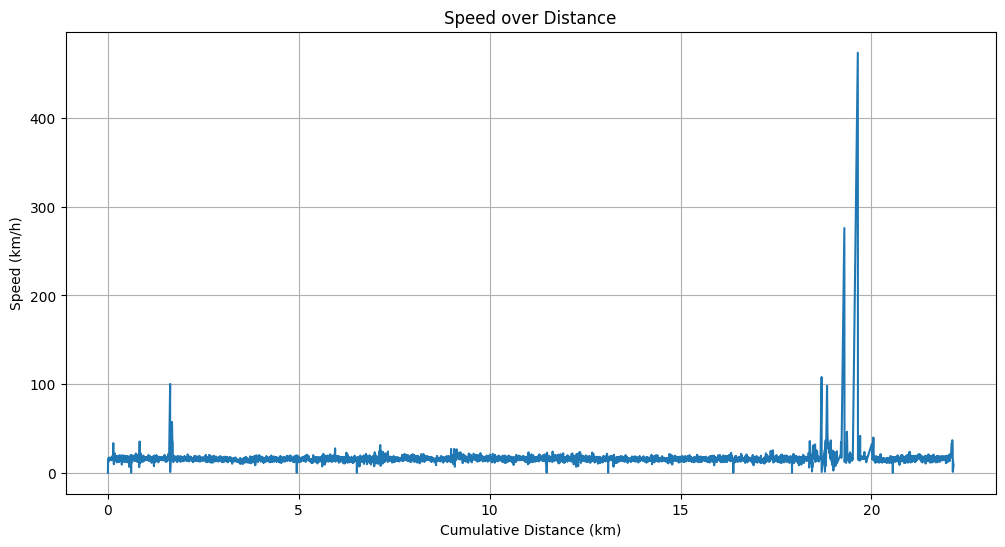

In [55]:
import matplotlib.pyplot as plt

# Calculate cumulative distance
df_gpx_specific['cumulative_distance_km'] = df_gpx_specific['distance_km'].cumsum()

# Create the plot
plt.figure(figsize=(12, 6))
plt.plot(df_gpx_specific['cumulative_distance_km'], df_gpx_specific['speed_kmh'])
plt.xlabel('Cumulative Distance (km)')
plt.ylabel('Speed (km/h)')
plt.title('Speed over Distance')
plt.grid(True)
plt.show()

### Aggregating Speed by Kilometer Segment (GPX Data)

To analyze speed more systematically, this section aggregates the GPX speed data into 1-kilometer segments. For each segment, the average speed is calculated, providing a segmented view of performance across the entire route. This aggregation helps in smoothing out minor fluctuations and highlights significant changes in pace over larger intervals.

In [56]:
# Define segment size (e.g., 1 km)
segment_size_km = 1

# Create a column for kilometer segments
df_gpx_specific['km_segment'] = (df_gpx_specific['cumulative_distance_km'] // segment_size_km).astype(int)

# Group by kilometer segment and calculate the mean speed
aggregated_speed_by_km = df_gpx_specific.groupby('km_segment')['speed_kmh'].mean().reset_index()
aggregated_speed_by_km.rename(columns={'speed_kmh': 'average_speed_kmh'}, inplace=True)

print(f"Aggregated Speed Data by {segment_size_km}-kilometer Segment:")
display(aggregated_speed_by_km.head())
print("...")
display(aggregated_speed_by_km.tail())

Aggregated Speed Data by 1-kilometer Segment:


,km_segment,average_speed_kmh
0,0,15.457645
1,1,16.311491
2,2,15.502090
3,3,14.473144
4,4,15.380595


...


,km_segment,average_speed_kmh
18,18,17.823088
19,19,21.865836
20,20,15.315281
21,21,15.885210
22,22,15.687215


### Visualizing Average Speed by Kilometer Segment (GPX Data)

This bar chart presents the average speed for each 1-kilometer segment, based on the GPX data. It offers a clear, segment-by-segment comparison of average speed, making it easier to pinpoint specific kilometer intervals where performance was notably different (e.g., faster or slower sections).

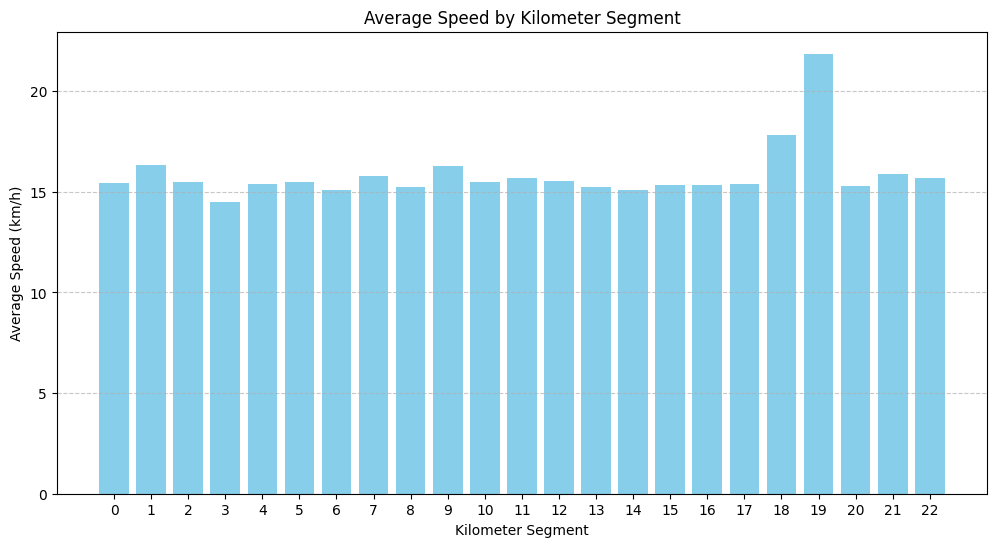

In [57]:
import matplotlib.pyplot as plt

plt.figure(figsize=(12, 6))
plt.bar(aggregated_speed_by_km['km_segment'], aggregated_speed_by_km['average_speed_kmh'], color='skyblue')
plt.xlabel('Kilometer Segment')
plt.ylabel('Average Speed (km/h)')
plt.title('Average Speed by Kilometer Segment')
plt.xticks(aggregated_speed_by_km['km_segment'])
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()

### Raw Speed Data for Kilometer Segment 19 (GPX Data)

Given an exceptionally high average speed observed in kilometer segment 19 (approximately 21.87 km/h or 2min44s/km pace) from the aggregated GPX data, this plot focuses on the raw speed data within that specific segment. By visualizing every recorded speed point, we can investigate whether the high average was due to a sustained high speed or an isolated spike, potentially indicating a GPS anomaly or an actual burst of speed.

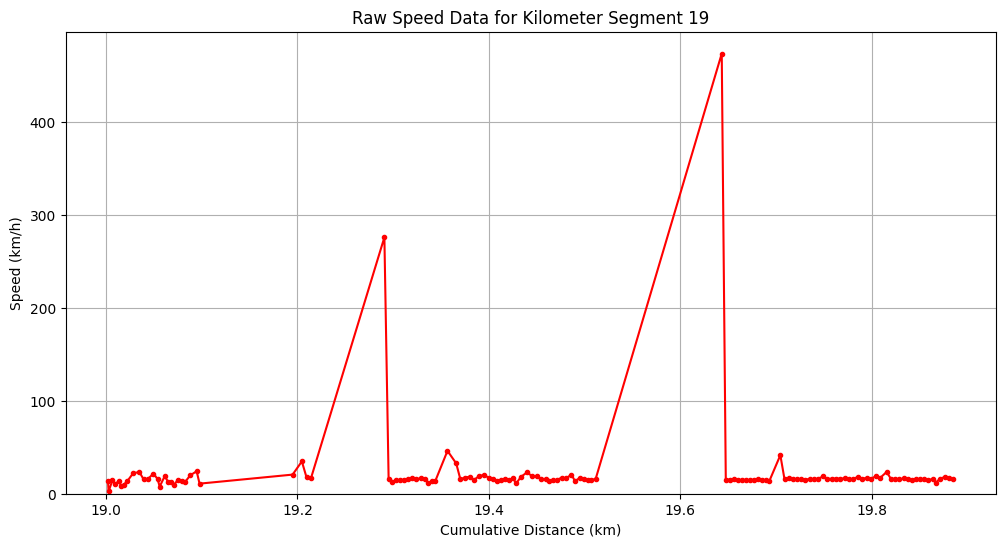

In [58]:
import matplotlib.pyplot as plt

# Filter data for kilometer segment 19
segment_19_data = df_gpx_specific[df_gpx_specific['km_segment'] == 19]

plt.figure(figsize=(12, 6))
plt.plot(segment_19_data['cumulative_distance_km'], segment_19_data['speed_kmh'], color='red', marker='.')
plt.xlabel('Cumulative Distance (km)')
plt.ylabel('Speed (km/h)')
plt.title('Raw Speed Data for Kilometer Segment 19')
plt.grid(True)
plt.ylim(bottom=0) # Ensure y-axis starts at 0
plt.show()

### Parsing Apple Health Export XML Data

This section introduces a function, `parse_apple_health_xml`, designed to extract various health metrics from the `export.xml` file generated by Apple Health. The function parses the XML structure, converts relevant attributes into a pandas DataFrame, and ensures proper data types for dates and numerical values. It also handles potential file not found errors and XML parsing issues, making the health data ready for analysis.

In [59]:
import xml.etree.ElementTree as ET
import pandas as pd
import os # Import os module

file_path = '/content/apple_health_export/apple_health_export/export.xml'

def parse_apple_health_xml(xml_file_path):
    if not os.path.exists(xml_file_path):
        print(f"Error: The file does not exist at the specified path: {xml_file_path}")
        print("Please ensure the ZIP file was extracted correctly and the path is accurate by running the extraction cell again.")
        return None
    try:
        tree = ET.parse(xml_file_path)
        root = tree.getroot()

        data = []
        for record in root.findall('.//Record'):
            record_data = record.attrib
            data.append(record_data)

        df = pd.DataFrame(data)
        # Convert relevant columns to appropriate types if they exist
        if 'creationDate' in df.columns: df['creationDate'] = pd.to_datetime(df['creationDate'])
        if 'startDate' in df.columns: df['startDate'] = pd.to_datetime(df['startDate'])
        if 'endDate' in df.columns: df['endDate'] = pd.to_datetime(df['endDate'])
        if 'value' in df.columns: df['value'] = pd.to_numeric(df['value'], errors='coerce')
        if 'duration' in df.columns: df['duration'] = pd.to_numeric(df['duration'], errors='coerce')

        return df
    except ET.ParseError as e:
        print(f"Error parsing XML file {xml_file_path}: {e}")
        return None
    except Exception as e:
        print(f"An unexpected error occurred: {e}")
        return None

# Analyze the XML file
df_health_data = parse_apple_health_xml(file_path)

if df_health_data is not None:
    print("\nHead of the parsed Apple Health XML data:")
    display(df_health_data.head())
    print(f"\nTotal records: {len(df_health_data)}")
    print("\nAvailable record types:")
    display(df_health_data['type'].value_counts().head(10))
else:
    print(f"Failed to parse data from {file_path}.")


Head of the parsed Apple Health XML data:


,type,sourceName,sourceVersion,unit,creationDate,startDate,endDate,value,device
0,HKQuantityTypeIdentifierHeight,Safouan’s Apple Watch,11.0,cm,2024-12-08 20:12:12-04:00,2024-12-08 20:12:12-04:00,2024-12-08 20:12:12-04:00,171.000,NaN
1,HKQuantityTypeIdentifierBodyMass,Safouan’s Apple Watch,11.0,kg,2024-12-08 20:12:12-04:00,2024-12-08 20:12:12-04:00,2024-12-08 20:12:12-04:00,63.000,NaN
2,HKQuantityTypeIdentifierBodyMass,Home Workouts,247,kg,2025-07-09 00:14:29-04:00,2025-07-09 00:14:29-04:00,2025-07-09 00:14:29-04:00,59.500,NaN
3,HKQuantityTypeIdentifierBodyMass,Home Workouts,260,kg,2025-11-13 20:03:15-04:00,2025-11-13 20:03:15-04:00,2025-11-13 20:03:15-04:00,60.000,NaN
4,HKQuantityTypeIdentifierHeartRate,Safouan’s Apple Watch,11.0,count/min,2024-12-08 16:20:38-04:00,2024-12-08 16:19:36-04:00,2024-12-08 16:19:36-04:00,65.646,"<<HKDevice: 0xbe8a6dbc0>, name:Apple Watch, ma..."



Total records: 1211380

Available record types:


,count
type,
HKQuantityTypeIdentifierHeartRate,174277
HKQuantityTypeIdentifierBasalEnergyBurned,167047
HKQuantityTypeIdentifierActiveEnergyBurned,153592
HKQuantityTypeIdentifierPhysicalEffort,141802
HKQuantityTypeIdentifierDistanceWalkingRunning,120454
HKQuantityTypeIdentifierStepCount,102421
HKQuantityTypeIdentifierRunningPower,65056
HKQuantityTypeIdentifierRunningSpeed,64985
HKQuantityTypeIdentifierAppleExerciseTime,32496


### Filtering Running Speed Data from XML

This code block filters the parsed Apple Health XML data to isolate records specifically related to 'HKQuantityTypeIdentifierRunningSpeed' (running speed). It further narrows down the data to a particular date (2026-05-03) to focus on the running activity that corresponds with the previously analyzed GPX data. The head of the filtered DataFrame and the total number of records are displayed for verification.

In [60]:
import pandas as pd

# Filter for the specific record type
df_running_speed = df_health_data[df_health_data['type'] == 'HKQuantityTypeIdentifierRunningSpeed']

# Filter for the specific date
# Ensure 'startDate' is datetime type, which it should be from parse_apple_health_xml function
df_running_speed_2026_05_03 = df_running_speed[df_running_speed['startDate'].dt.date == pd.to_datetime('2026-05-03').date()]

print("Filtered data for 'HKQuantityTypeIdentifierRunningSpeed' on 2026-05-03:")
display(df_running_speed_2026_05_03.head())
print(f"\nTotal records for running speed on 2026-05-03: {len(df_running_speed_2026_05_03)}")

Filtered data for 'HKQuantityTypeIdentifierRunningSpeed' on 2026-05-03:


,type,sourceName,sourceVersion,unit,creationDate,startDate,endDate,value,device
1053726,HKQuantityTypeIdentifierRunningSpeed,Safouan’s Apple Watch,26.4,km/hr,2026-05-03 08:30:11-04:00,2026-05-03 08:30:10-04:00,2026-05-03 08:30:10-04:00,9.73261,"<<HKDevice: 0xbe8a6ee20>, name:Apple Watch, ma..."
1053727,HKQuantityTypeIdentifierRunningSpeed,Safouan’s Apple Watch,26.4,km/hr,2026-05-03 08:30:16-04:00,2026-05-03 08:30:13-04:00,2026-05-03 08:30:13-04:00,10.87530,"<<HKDevice: 0xbe8a6ee20>, name:Apple Watch, ma..."
1053728,HKQuantityTypeIdentifierRunningSpeed,Safouan’s Apple Watch,26.4,km/hr,2026-05-03 08:30:18-04:00,2026-05-03 08:30:16-04:00,2026-05-03 08:30:16-04:00,12.06270,"<<HKDevice: 0xbe8a6ee20>, name:Apple Watch, ma..."
1053729,HKQuantityTypeIdentifierRunningSpeed,Safouan’s Apple Watch,26.4,km/hr,2026-05-03 08:30:21-04:00,2026-05-03 08:30:18-04:00,2026-05-03 08:30:18-04:00,16.62790,"<<HKDevice: 0xbe8a6ee20>, name:Apple Watch, ma..."
1053730,HKQuantityTypeIdentifierRunningSpeed,Safouan’s Apple Watch,26.4,km/hr,2026-05-03 08:30:23-04:00,2026-05-03 08:30:21-04:00,2026-05-03 08:30:21-04:00,16.38880,"<<HKDevice: 0xbe8a6ee20>, name:Apple Watch, ma..."



Total records for running speed on 2026-05-03: 1968


### Visualizing Running Speed Over Time (XML Data)

This plot displays the 'HKQuantityTypeIdentifierRunningSpeed' data from the Apple Health XML export over time for the specified date (2026-05-03). The data is sorted by `endDate` to ensure a chronological representation of speed fluctuations during the activity. This visualization helps in observing the detailed speed profile recorded by the Apple Watch or other health sensors.

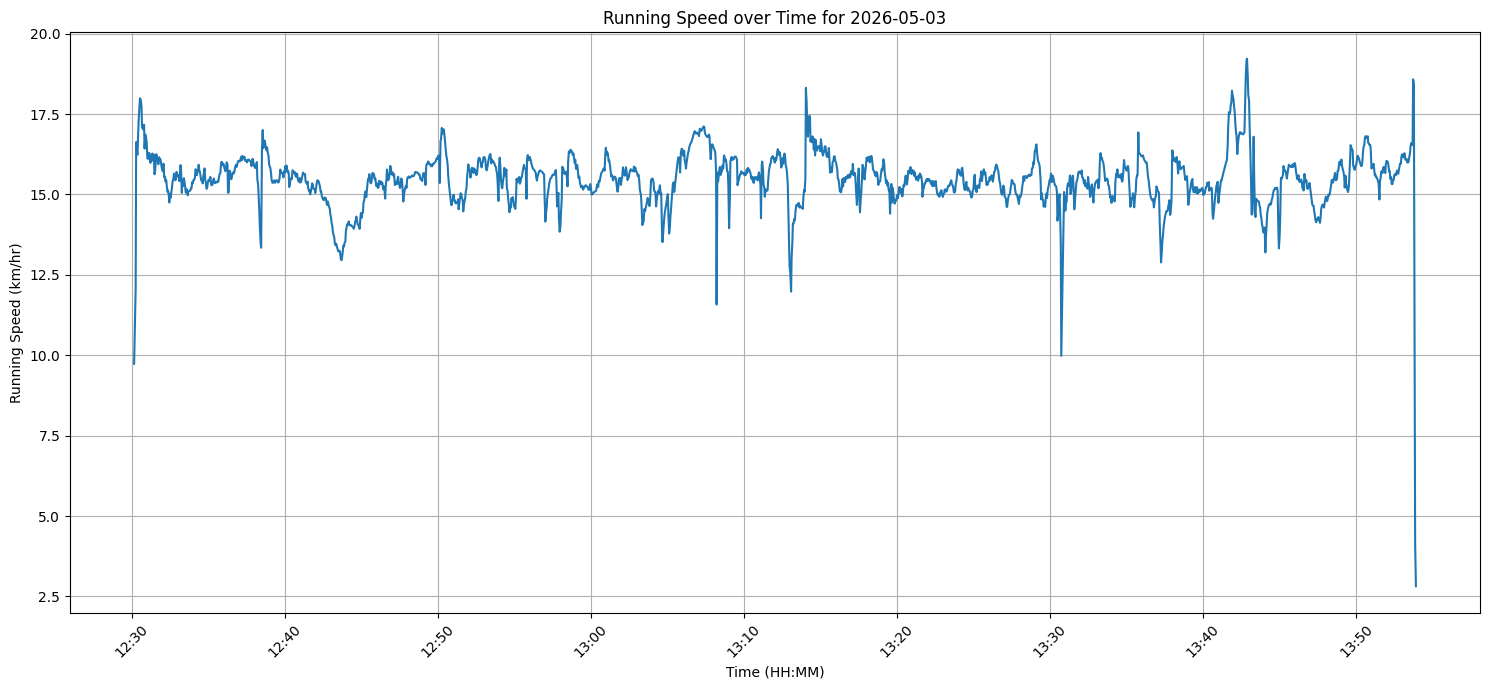

In [61]:
import matplotlib.pyplot as plt
import matplotlib.dates as mdates # Import mdates for date formatting

# Ensure the data is sorted by endDate for a proper time-series plot
df_running_speed_2026_05_03 = df_running_speed_2026_05_03.sort_values(by='endDate')

plt.figure(figsize=(15, 7))
plt.plot(df_running_speed_2026_05_03['endDate'], df_running_speed_2026_05_03['value'])
plt.xlabel('Time (HH:MM)') # Updated label
plt.ylabel('Running Speed (km/hr)')
plt.title('Running Speed over Time for 2026-05-03')
plt.grid(True)

# Format x-axis to show only HH:MM
date_form = mdates.DateFormatter('%H:%M')
plt.gca().xaxis.set_major_formatter(date_form)
plt.xticks(rotation=45) # Rotate labels for better readability

plt.tight_layout()
plt.show()


* The first significant dip in speed correlates with an increasing elevation (ramp).
* Other dips are attributed to stops at hydration stations.
* The observed spikes are considered realistic due to controlled bursts of speed.

### Merging XML Running Speed with GPX Kilometer Segments

This section focuses on integrating the granular 'HKQuantityTypeIdentifierRunningSpeed' data from the Apple Health XML with the kilometer segment information derived from the GPX data. A time-series aware `merge_asof` operation is performed to match each XML speed record to its closest GPX timestamp, thereby assigning a kilometer segment to each speed measurement. The result is an aggregated DataFrame showing the average running speed from the XML data per kilometer segment, enabling direct comparison with GPX-based speed calculations.

In [62]:
import numpy as np
import pandas as pd

# Select relevant columns from df_gpx_specific for merging and rename 'time' to 'endDate'
gpx_for_for_merge_asof = df_gpx_specific[['time', 'cumulative_distance_km', 'km_segment']].copy()
gpx_for_for_merge_asof.rename(columns={'time': 'endDate'}, inplace=True)

# Ensure both dataframes' 'endDate' columns are timezone-naive UTC for consistent merging
# Convert to UTC and then make naive
gpx_for_for_merge_asof['endDate'] = gpx_for_for_merge_asof['endDate'].dt.tz_convert('UTC').dt.tz_localize(None)
df_running_speed_2026_05_03['endDate'] = df_running_speed_2026_05_03['endDate'].dt.tz_convert('UTC').dt.tz_localize(None)

# Ensure both dataframes are sorted by the 'endDate' column for merge_asof to work correctly
gpx_for_for_merge_asof.sort_values(by='endDate', inplace=True)
df_running_speed_2026_05_03.sort_values(by='endDate', inplace=True)

# Perform a time-series aware merge using merge_asof
# This will match each running speed record to the nearest GPX point in time
merged_speed_and_segments = pd.merge_asof(
    df_running_speed_2026_05_03,
    gpx_for_for_merge_asof,
    on='endDate',
    direction='nearest' # Matches to the nearest timestamp in gpx_for_for_merge_asof
)

# Drop rows where 'km_segment' might be NaN if no suitable GPX point was found (unlikely in this case)
merged_speed_and_segments.dropna(subset=['km_segment'], inplace=True)
merged_speed_and_segments['km_segment'] = merged_speed_and_segments['km_segment'].astype(int)

# Aggregate the average running speed ('value') by 'km_segment'
aggregated_running_speed_xml_by_km = merged_speed_and_segments.groupby('km_segment')['value'].mean().reset_index()
aggregated_running_speed_xml_by_km.rename(columns={'value': 'average_running_speed_xml_kmh'}, inplace=True)

print("Aggregated Running Speed from XML Data by Kilometer Segment:")
display(aggregated_running_speed_xml_by_km.head())
print("...")
display(aggregated_running_speed_xml_by_km.tail())

Aggregated Running Speed from XML Data by Kilometer Segment:


,km_segment,average_running_speed_xml_kmh
0,0,15.710005
1,1,15.674900
2,2,15.661904
3,3,14.427089
4,4,15.481059


...


,km_segment,average_running_speed_xml_kmh
18,18,16.224867
19,19,14.879902
20,20,15.242443
21,21,15.952256
22,22,14.305367


### Visualizing Average Running Speed by Kilometer Segment (XML Data)

This bar chart presents the average 'HKQuantityTypeIdentifierRunningSpeed' (from the Apple Health XML data) for each 1-kilometer segment. Similar to the GPX speed visualization, this plot provides a segmented view of the average speed as recorded by the health sensors, allowing for a direct comparison with the GPX-derived speeds for the same segments.

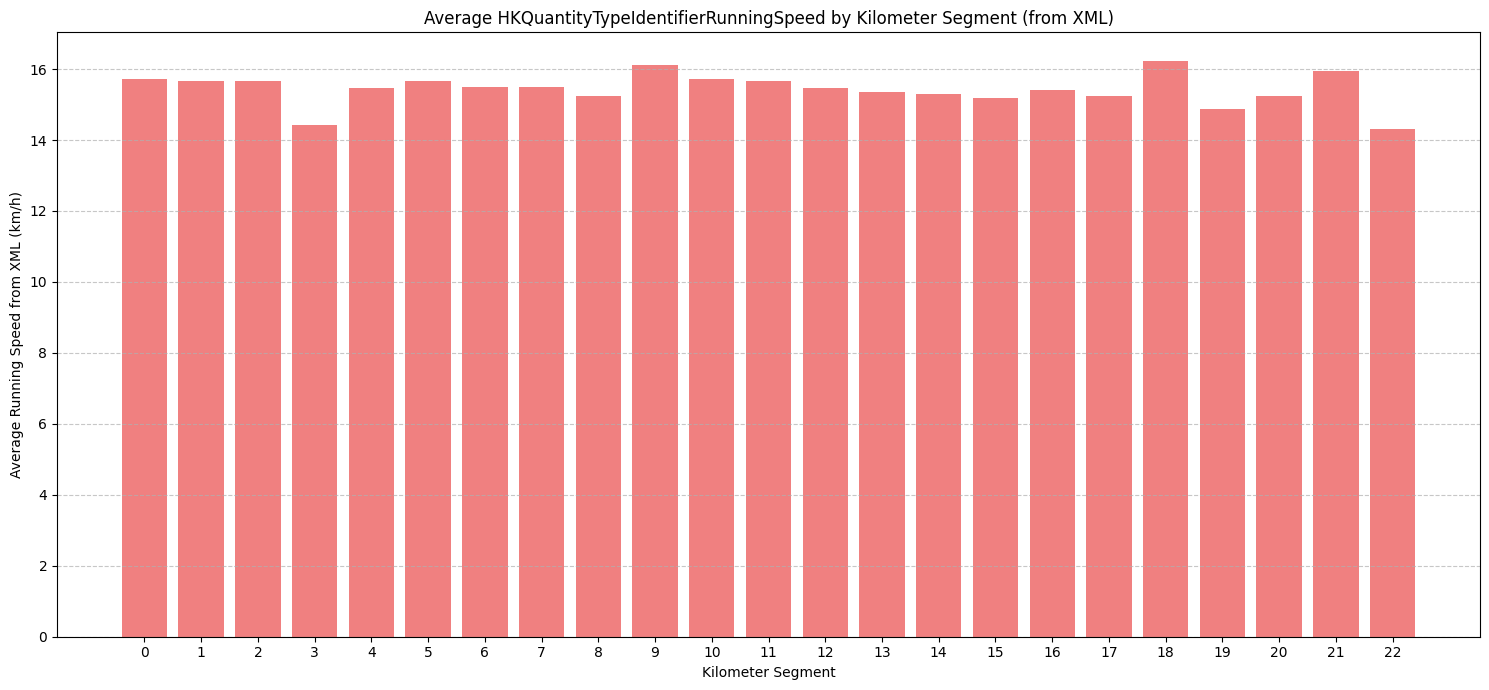

In [63]:
import matplotlib.pyplot as plt

plt.figure(figsize=(15, 7))
plt.bar(
    aggregated_running_speed_xml_by_km['km_segment'],
    aggregated_running_speed_xml_by_km['average_running_speed_xml_kmh'],
    color='lightcoral'
)
plt.xlabel('Kilometer Segment')
plt.ylabel('Average Running Speed from XML (km/h)')
plt.title('Average HKQuantityTypeIdentifierRunningSpeed by Kilometer Segment (from XML)')
plt.xticks(aggregated_running_speed_xml_by_km['km_segment'])
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

### Resampling and Plotting Average Running Speed per Minute (XML Data)

This cell refines the 'HKQuantityTypeIdentifierRunningSpeed' data from the XML by resampling it to calculate the average speed per minute. This process smooths out very fine-grained fluctuations and provides a clearer view of overall pace changes throughout the activity. The resulting plot visualizes this minute-by-minute average speed, making it easier to identify trends and sustained changes in running intensity.

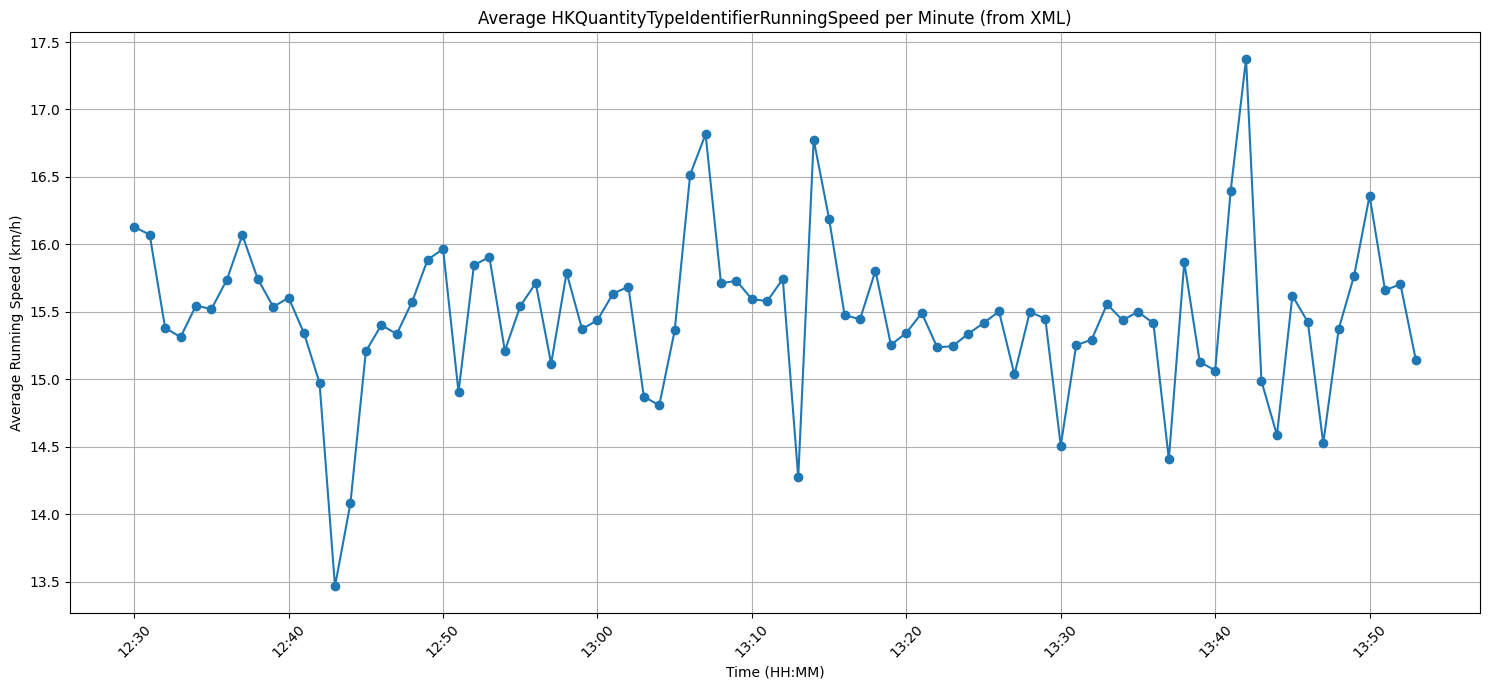

In [64]:
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import pandas as pd # Added missing import

# Ensure 'endDate' is a datetime object and sort it
df_running_speed_2026_05_03['endDate'] = pd.to_datetime(df_running_speed_2026_05_03['endDate'])
df_running_speed_2026_05_03 = df_running_speed_2026_05_03.sort_values(by='endDate')

# Set 'endDate' as the index for resampling
df_resampled_minute = df_running_speed_2026_05_03.set_index('endDate')

# Resample the data to get the average speed per minute
average_speed_per_minute = df_resampled_minute['value'].resample('1min').mean().reset_index()

# Plotting the average speed per minute
plt.figure(figsize=(15, 7))
plt.plot(average_speed_per_minute['endDate'], average_speed_per_minute['value'], marker='o', linestyle='-')
plt.xlabel('Time (HH:MM)')
plt.ylabel('Average Running Speed (km/h)')
plt.title('Average HKQuantityTypeIdentifierRunningSpeed per Minute (from XML)')
plt.grid(True);

# Format x-axis to show only HH:MM
date_form = mdates.DateFormatter('%H:%M')
plt.gca().xaxis.set_major_formatter(date_form)
plt.xticks(rotation=45) # Rotate labels to prevent overlap

plt.tight_layout()
plt.show()

### Merging Aggregated GPX and XML Speed Data

This section merges the two aggregated DataFrames: `aggregated_speed_by_km` (derived from GPX data) and `aggregated_running_speed_xml_by_km` (derived from Apple Health XML data). The merge is performed on the 'km_segment' column, creating a unified DataFrame that allows for a direct, side-by-side comparison of average speeds calculated from both data sources for each kilometer segment.

In [65]:
import pandas as pd

merged_gpx_and_xml_speed = pd.merge(
    aggregated_speed_by_km,
    aggregated_running_speed_xml_by_km,
    on='km_segment',
    how='outer'
)

print("Merged GPX and XML Average Speed Data by Kilometer Segment:")
display(merged_gpx_and_xml_speed.head())
display(merged_gpx_and_xml_speed.tail())

Merged GPX and XML Average Speed Data by Kilometer Segment:


,km_segment,average_speed_kmh,average_running_speed_xml_kmh
0,0,15.457645,15.710005
1,1,16.311491,15.674900
2,2,15.502090,15.661904
3,3,14.473144,14.427089
4,4,15.380595,15.481059


,km_segment,average_speed_kmh,average_running_speed_xml_kmh
18,18,17.823088,16.224867
19,19,21.865836,14.879902
20,20,15.315281,15.242443
21,21,15.885210,15.952256
22,22,15.687215,14.305367


### Comparison of Average Speed by Kilometer Segment (GPX vs. XML)

This bar chart provides a comparative visualization of average speeds per kilometer segment, drawing from both the GPX data and the Apple Health XML data. By plotting these two metrics side-by-side for each segment, it becomes evident where discrepancies or correlations exist between GPS-derived speed and sensor-derived running speed. This comparison is crucial for understanding the reliability and specific differences between the two data sources.

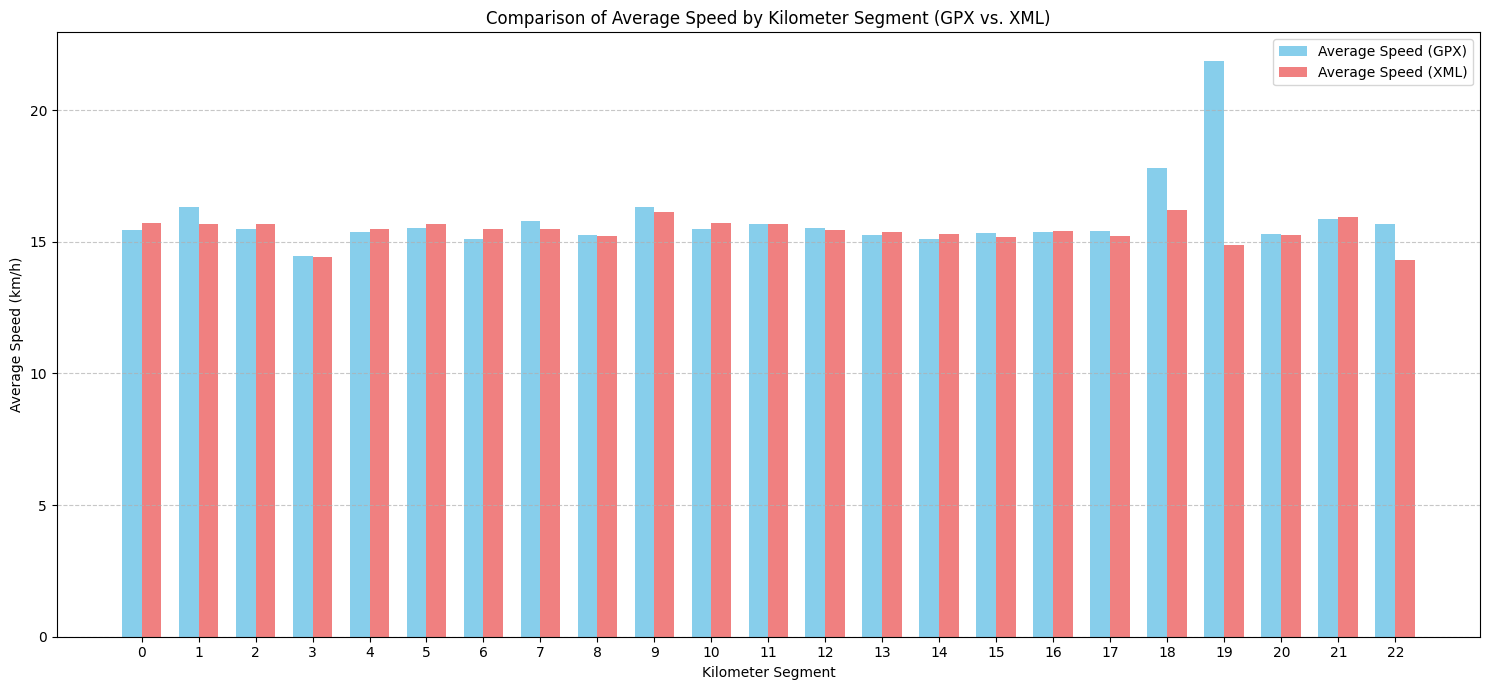

In [66]:
import matplotlib.pyplot as plt

plt.figure(figsize=(15, 7))
bar_width = 0.35
index = merged_gpx_and_xml_speed['km_segment']

plt.bar(index - bar_width/2, merged_gpx_and_xml_speed['average_speed_kmh'], bar_width, label='Average Speed (GPX)', color='skyblue')
plt.bar(index + bar_width/2, merged_gpx_and_xml_speed['average_running_speed_xml_kmh'], bar_width, label='Average Speed (XML)', color='lightcoral')

plt.xlabel('Kilometer Segment')
plt.ylabel('Average Speed (km/h)')
plt.title('Comparison of Average Speed by Kilometer Segment (GPX vs. XML)')
plt.xticks(index)
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.legend()
plt.tight_layout()
plt.show()

### Summary



*  Export.xml data looks more accurate than GPX data as it applies a rolling smoothing to eliminate sudden fluctuations.
Exporting data in XML is often perceived as more accurate than exporting solely to GPX because GPX files natively strip out third-party sensor data (like heart rate, cadence, or power). GPX is simply an XML format specifically designed for basic GPS coordinates.
*   Export GPX data analysis correlated with https://colab.research.google.com/drive/1qgXGVvbodC_qRzZNzehREyFnzAhYG326#scrollTo=79a30347 findings.





